# Khai báo thư viện

In [9]:
import json
import os
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm

# Nguồn

In [5]:
DATASET_NAME = "iu_xray"  # đổi thành mimic_cxr nếu cần

IMAGE_DIR = r"G:\My Drive\NCKH\A3Net-main\data\iu_xray\images"
ANN_PATH = r"G:\My Drive\NCKH\A3Net-main\data\iu_xray\annotation.json"
# SPLIT_PATH = "data/iu_xray/split.json"  # nếu có


# Khảo sát sơ lược report

In [8]:
# Load annotation
with open(ANN_PATH, 'r') as f:
    annotations = json.load(f)

print("Top-level keys:", annotations.keys())
print("Train size:", len(annotations['train']))
print("Val size:", len(annotations['val']))
print("Test size:", len(annotations['test']))

Top-level keys: dict_keys(['train', 'val', 'test'])
Train size: 2069
Val size: 296
Test size: 590


# Cấu trúc report

In [ ]:
train_anns = annotations['train']
print("Example annotation keys:", train_anns[0].keys())

Example annotation keys: {'id': 'CXR2384_IM-0942', 'report': 'The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degenerative changes are present in the spine.', 'image_path': ['CXR2384_IM-0942/0.png', 'CXR2384_IM-0942/1.png'], 'split': 'train'}


In [20]:
# Tạo dataframe từ phần train
train_data = []
for ann in tqdm(train_anns):
    img_id = ann['id']
    img_path = os.path.join(IMAGE_DIR, img_id)
    report = ann['report']
    image_path = ann['image_path']
    
    train_data.append({
        'image_id': img_id,
        'image_path': img_path,
        'report': report,
        'findings': image_path,
    })
train_df = pd.DataFrame(train_data)
print(train_df.head())

100%|██████████| 2069/2069 [00:00<00:00, 256389.49it/s]

          image_id                                         image_path  \
0  CXR2384_IM-0942  G:\My Drive\NCKH\A3Net-main\data\iu_xray\image...   
1  CXR2926_IM-1328  G:\My Drive\NCKH\A3Net-main\data\iu_xray\image...   
2  CXR1451_IM-0291  G:\My Drive\NCKH\A3Net-main\data\iu_xray\image...   
3  CXR2887_IM-1289  G:\My Drive\NCKH\A3Net-main\data\iu_xray\image...   
4  CXR1647_IM-0424  G:\My Drive\NCKH\A3Net-main\data\iu_xray\image...   

                                              report  \
0  The heart size and pulmonary vascularity appea...   
1  Cardiac and mediastinal contours are within no...   
2  Left lower lobe calcified granuloma. Heart siz...   
3  The cardiomediastinal silhouette is normal in ...   
4  The lungs are clear bilaterally. Specifically,...   

                                         findings  
0  [CXR2384_IM-0942/0.png, CXR2384_IM-0942/1.png]  
1  [CXR2926_IM-1328/0.png, CXR2926_IM-1328/1.png]  
2  [CXR1451_IM-0291/0.png, CXR1451_IM-0291/1.png]  
3  [CXR2887_IM-1

In [23]:
# Tạo dataframe từ phần train
train_data = []
for ann in tqdm(train_anns):
    img_id = ann['id']
    img_path = os.path.join(IMAGE_DIR, img_id)
    report = ann['report']
    image_path = ann['image_path']
    
    train_data.append({
        'image_id': img_id,
        'image_path': img_path,
        'report': report,
        'findings': image_path,
    })
train_df = pd.DataFrame(train_data)

# Hiển thị đẹp hơn
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 120)
pd.set_option('display.colheader_justify', 'left')

display_df = train_df.head().copy()
display_df['report'] = display_df['report'].str[:60] + '...'
display_df['image_path'] = display_df['image_path'].str[-40:]
display_df['findings'] = display_df['findings'].apply(
    lambda x: f"[{x[0]}, {x[1]}]" if isinstance(x, list) else str(x)
)

print(f"\n{'='*80}")
print(f"  TRAIN DATASET  |  Tổng số mẫu: {len(train_df)}")
print(f"{'='*80}")
print(display_df.to_string(index=True))
print(f"{'='*80}\n")

100%|██████████| 2069/2069 [00:00<00:00, 258228.14it/s]


  TRAIN DATASET  |  Tổng số mẫu: 2069
  image_id         image_path                                report                                                           findings                                       
0  CXR2384_IM-0942  main\data\iu_xray\images\CXR2384_IM-0942  The heart size and pulmonary vascularity appear within norma...  [CXR2384_IM-0942/0.png, CXR2384_IM-0942/1.png]
1  CXR2926_IM-1328  main\data\iu_xray\images\CXR2926_IM-1328  Cardiac and mediastinal contours are within normal limits. T...  [CXR2926_IM-1328/0.png, CXR2926_IM-1328/1.png]
2  CXR1451_IM-0291  main\data\iu_xray\images\CXR1451_IM-0291  Left lower lobe calcified granuloma. Heart size normal. No p...  [CXR1451_IM-0291/0.png, CXR1451_IM-0291/1.png]
3  CXR2887_IM-1289  main\data\iu_xray\images\CXR2887_IM-1289  The cardiomediastinal silhouette is normal in size and conto...  [CXR2887_IM-1289/0.png, CXR2887_IM-1289/1.png]
4  CXR1647_IM-0424  main\data\iu_xray\images\CXR1647_IM-0424  The lungs are clear bilateral

Example annotation keys: dict_keys(['id', 'report', 'image_path', 'split'])
Report: Cardiac and mediastinal contours are within normal limits. The lungs are clear. Bony structures are intact.
Image paths: ['CXR2926_IM-1328/0.png', 'CXR2926_IM-1328/1.png']


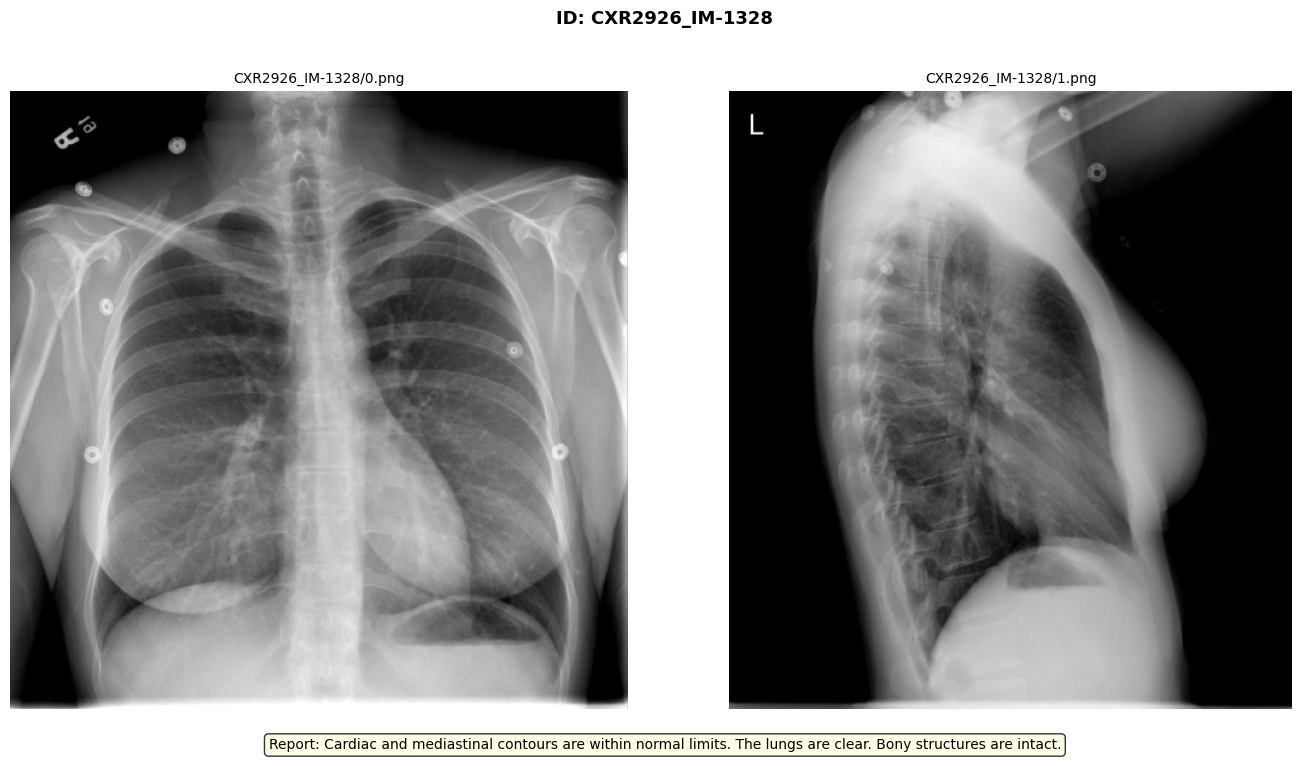

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Ví dụ về một annotation kèm theo hình ảnh
example_ann = train_anns[1]
print("Example annotation keys:", example_ann.keys())
print("Report:", example_ann['report'])
print("Image paths:", example_ann['image_path'])

# Vẽ hình ảnh kèm report
image_paths = example_ann['image_path']  # list các ảnh (thường là 2: frontal + lateral)
n_imgs = len(image_paths)

fig, axes = plt.subplots(1, n_imgs, figsize=(7 * n_imgs, 7))
if n_imgs == 1:
    axes = [axes]

for ax, img_rel_path in zip(axes, image_paths):
    full_path = os.path.join(IMAGE_DIR, img_rel_path)
    img = mpimg.imread(full_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(img_rel_path, fontsize=10)
    ax.axis('off')

# Thêm report làm caption phía dưới
fig.text(
    0.5, -0.02,
    f"Report: {example_ann['report']}",
    ha='center', va='top',
    fontsize=10, wrap=True,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
    transform=fig.transFigure
)

plt.suptitle(f"ID: {example_ann['id']}", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


  THỐNG KÊ ĐỘ DÀI REPORT (theo số từ)
count    2069.00
mean       31.77
std        14.21
min         7.00
25%        22.00
50%        29.00
75%        39.00
max       149.00

Mode  : 30 từ
Median: 29.0 từ


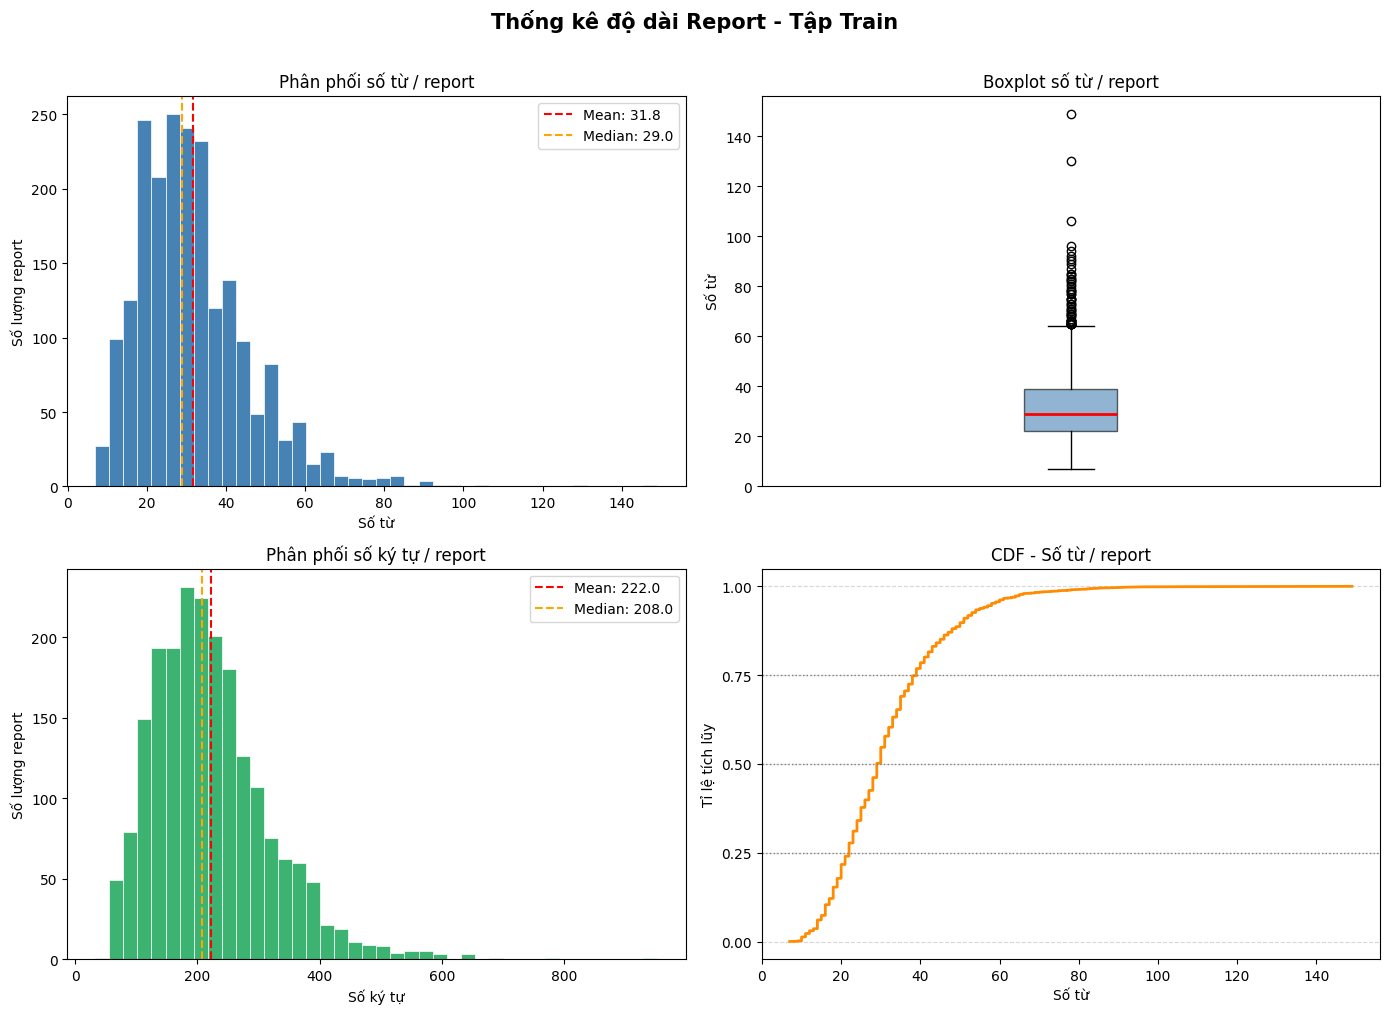

In [ ]:
# Tính độ dài report (theo từ và ký tự)
train_df['report_word_count']  = train_df['report'].apply(lambda x: len(x.split()))
train_df['report_char_count']  = train_df['report'].apply(len)

# Thống kê mô tả
print("="*50)
print("  THỐNG KÊ ĐỘ DÀI REPORT (theo số từ)")
print("="*50)
print(train_df['report_word_count'].describe().round(2).to_string())
print(f"\nMode  : {train_df['report_word_count'].mode()[0]} từ")
print(f"Median: {train_df['report_word_count'].median():.1f} từ")
print("="*50)

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Thống kê độ dài Report - Tập Train", fontsize=15, fontweight='bold', y=1.01)

word_counts = train_df['report_word_count']
char_counts = train_df['report_char_count']

# 1. Histogram số từ
axes[0, 0].hist(word_counts, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0, 0].axvline(word_counts.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {word_counts.mean():.1f}')
axes[0, 0].axvline(word_counts.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {word_counts.median():.1f}')
axes[0, 0].set_title("Phân phối số từ / report")
axes[0, 0].set_xlabel("Số từ")
axes[0, 0].set_ylabel("Số lượng report")
axes[0, 0].legend()

# 2. Boxplot số từ
axes[0, 1].boxplot(word_counts, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6),
                   medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_title("Boxplot số từ / report")
axes[0, 1].set_ylabel("Số từ")
axes[0, 1].set_xticks([])

# 3. Histogram số ký tự
axes[1, 0].hist(char_counts, bins=40, color='mediumseagreen', edgecolor='white', linewidth=0.5)
axes[1, 0].axvline(char_counts.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {char_counts.mean():.1f}')
axes[1, 0].axvline(char_counts.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {char_counts.median():.1f}')
axes[1, 0].set_title("Phân phối số ký tự / report")
axes[1, 0].set_xlabel("Số ký tự")
axes[1, 0].set_ylabel("Số lượng report")
axes[1, 0].legend()

# 4. CDF (Cumulative Distribution)
sorted_words = np.sort(word_counts)
cdf = np.arange(1, len(sorted_words) + 1) / len(sorted_words)
axes[1, 1].plot(sorted_words, cdf, color='darkorange', linewidth=2)
axes[1, 1].axhline(0.25, color='gray',  linestyle=':', linewidth=1)
axes[1, 1].axhline(0.50, color='gray',  linestyle=':', linewidth=1)
axes[1, 1].axhline(0.75, color='gray',  linestyle=':', linewidth=1)
axes[1, 1].set_title("CDF - Số từ / report")
axes[1, 1].set_xlabel("Số từ")
axes[1, 1].set_ylabel("Tỉ lệ tích lũy")
axes[1, 1].set_yticks([0, 0.25, 0.5, 0.75, 1.0])
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import pandas as pd

# Các mốc phần trăm cần thống kê
percentiles = [10, 20, 25, 30, 40, 50, 60, 70, 75, 80, 90, 95, 99, 100]

# Tính theo số từ và số ký tự
word_counts = train_df['report_word_count']
char_counts = train_df['report_char_count']

rows = []
for p in percentiles:
    w = np.percentile(word_counts, p)
    c = np.percentile(char_counts, p)
    rows.append({
        'Phần trăm (%)': f'{p}%',
        'Số từ (words)': int(w),
        'Số ký tự (chars)': int(c),
        'Số report ≤ mức này': int(len(word_counts) * p / 100),
    })

percentile_df = pd.DataFrame(rows)

# Hiển thị bảng đẹp
print("\n" + "="*65)
print("   PHÂN PHỐI ĐỘ DÀI REPORT THEO MỐC PHẦN TRĂM - Tập Train")
print("="*65)
print(percentile_df.to_string(index=False))
print("="*65)
print(f"  Tổng số report: {len(word_counts)}")
print(f"  Mean  : {word_counts.mean():.1f} từ  |  {char_counts.mean():.1f} ký tự")
print(f"  Std   : {word_counts.std():.1f} từ   |  {char_counts.std():.1f} ký tự")
print("="*65)


   PHÂN PHỐI ĐỘ DÀI REPORT THEO MỐC PHẦN TRĂM - Tập Train
Phần trăm (%)  Số từ (words)  Số ký tự (chars)  Số report ≤ mức này
 10%           16            115                206                
 20%           20            140                413                
 25%           22            154                517                
 30%           23            165                620                
 40%           27            186                827                
 50%           29            208               1034                
 60%           32            230               1241                
 70%           36            254               1448                
 75%           39            272               1551                
 80%           41            291               1655                
 90%           51            351               1862                
 95%           58            392               1965                
 99%           78            528               2048      


   DUPLICATE REPORT DETECTION - Tập Train
  Tổng report       :   2069
  Report duy nhất   :   1728  (83.5%)
  Report bị lặp     :    341  (16.5%)
  Report phổ biến #1: 'The heart is normal in size. The mediastinum is unremarkable...'
                      → xuất hiện 29 lần (1.4%)
  Top 673 report duy nhất chiếm 50% toàn bộ tập train

  TOP 20 REPORT PHỔ BIẾN NHẤT
----------------------------------------------------------------------
   report_preview                                               frequency  percent (%)  cumulative (%)
1   The heart is normal in size. The mediastinum is unremar...  29         1.40          1.40         
2   Heart size normal. Lungs are clear. XXXX are normal. No...  25         1.21          2.61         
3   The heart and lungs have XXXX XXXX in the interval. Bot...  22         1.06          3.67         
4   The lungs are clear bilaterally. Specifically, no evide...  18         0.87          4.54         
5   Cardiac and mediastinal contours are with

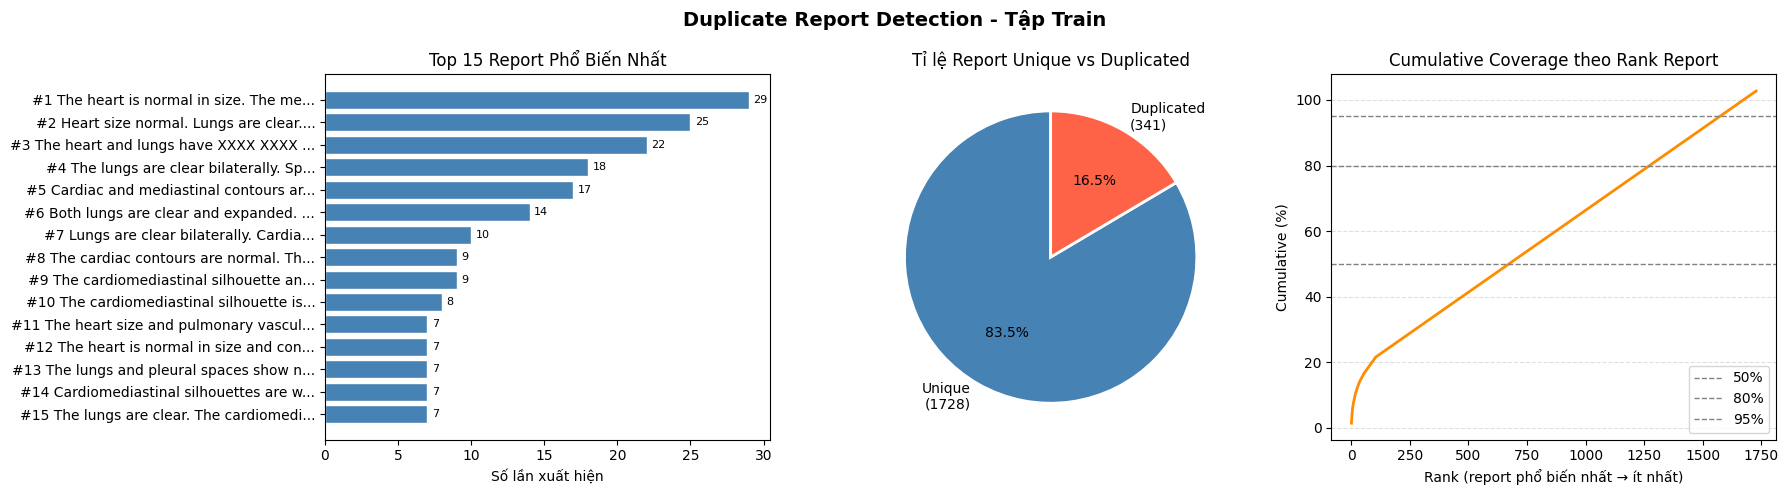

In [30]:
from collections import Counter

# ── 1. Tần suất từng report ──────────────────────────────────────────
report_counts = Counter(train_df['report'].str.strip())
report_freq_df = pd.DataFrame(report_counts.most_common(), columns=['report', 'frequency'])
report_freq_df['percent (%)'] = (report_freq_df['frequency'] / len(train_df) * 100).round(2)
report_freq_df['cumulative (%)'] = report_freq_df['percent (%)'].cumsum().round(2)
report_freq_df.index += 1  # rank bắt đầu từ 1

# ── 2. Thống kê tổng quan ────────────────────────────────────────────
n_total        = len(train_df)
n_unique       = len(report_freq_df)
n_duplicated   = n_total - n_unique
top1_report    = report_freq_df.iloc[0]
top1_cover     = report_freq_df[report_freq_df['cumulative (%)'] <= 50].shape[0]

print("\n" + "="*70)
print("   DUPLICATE REPORT DETECTION - Tập Train")
print("="*70)
print(f"  Tổng report       : {n_total:>6}")
print(f"  Report duy nhất   : {n_unique:>6}  ({n_unique/n_total*100:.1f}%)")
print(f"  Report bị lặp     : {n_duplicated:>6}  ({n_duplicated/n_total*100:.1f}%)")
print(f"  Report phổ biến #1: '{top1_report['report'][:60]}...'")
print(f"                      → xuất hiện {top1_report['frequency']} lần ({top1_report['percent (%)']:.1f}%)")
print(f"  Top {top1_cover} report duy nhất chiếm 50% toàn bộ tập train")
print("="*70)

# ── 3. Bảng Top 20 report phổ biến nhất ─────────────────────────────
print("\n  TOP 20 REPORT PHỔ BIẾN NHẤT")
print("-"*70)
display_top = report_freq_df.head(20).copy()
display_top['report_preview'] = display_top['report'].str[:55] + '...'
print(display_top[['report_preview', 'frequency', 'percent (%)', 'cumulative (%)']].to_string())
print("-"*70)

# ── 4. Phân nhóm theo tần suất ──────────────────────────────────────
bins   = [1, 2, 5, 10, 50, float('inf')]
labels = ['1 lần (unique)', '2–4 lần', '5–9 lần', '10–49 lần', '≥50 lần']
report_freq_df['freq_group'] = pd.cut(report_freq_df['frequency'], bins=bins, labels=labels, right=False)
group_stats = (
    report_freq_df.groupby('freq_group', observed=True)
    .agg(
        số_report_unique=('frequency', 'count'),
        tổng_xuất_hiện=('frequency', 'sum')
    )
    .assign(**{'chiếm (%)': lambda d: (d['tổng_xuất_hiện'] / n_total * 100).round(2)})
)

print("\n  PHÂN NHÓM THEO TẦN SUẤT")
print("-"*55)
print(group_stats.to_string())
print("-"*55)

# ── 5. Biểu đồ ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Duplicate Report Detection - Tập Train", fontsize=14, fontweight='bold')

# 5a. Bar chart Top 15
top15 = report_freq_df.head(15)
bars = axes[0].barh(
    [f"#{i} {r[:35]}..." for i, r in zip(top15.index, top15['report'])],
    top15['frequency'],
    color='steelblue', edgecolor='white'
)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Report Phổ Biến Nhất")
axes[0].set_xlabel("Số lần xuất hiện")
for bar, val in zip(bars, top15['frequency']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=8)

# 5b. Pie chart: unique vs duplicated
axes[1].pie(
    [n_unique, n_duplicated],
    labels=[f'Unique\n({n_unique})', f'Duplicated\n({n_duplicated})'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title("Tỉ lệ Report Unique vs Duplicated")

# 5c. Cumulative coverage
axes[2].plot(report_freq_df.index, report_freq_df['cumulative (%)'],
             color='darkorange', linewidth=2)
for threshold in [50, 80, 95]:
    axes[2].axhline(threshold, linestyle='--', linewidth=1, color='gray',
                    label=f'{threshold}%')
axes[2].set_title("Cumulative Coverage theo Rank Report")
axes[2].set_xlabel("Rank (report phổ biến nhất → ít nhất)")
axes[2].set_ylabel("Cumulative (%)")
axes[2].legend()
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Sentence embedding clustering

c:\Windows\System32\xray_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading SentenceTransformer model...


c:\Windows\System32\xray_env\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Embedding 1728 unique reports...


Batches: 100%|██████████| 27/27 [00:04<00:00,  5.83it/s]


Embedding shape: (2069, 384)

Finding optimal K...


100%|██████████| 14/14 [00:09<00:00,  1.51it/s]



→ Optimal K by Silhouette: 15

   CLUSTER SUMMARY  (K=15)
    Cluster  Số report  Tỉ lệ (%) Report đại diện                                                                     
1    1       275        13.29      The cardiomediastinal silhouette is normal in size and contour. Lungs are clear ...
2   11       239        11.55      Lungs are clear. There is no pleural effusion or pneumothorax. The heart and med...
3    9       207        10.00      The heart is normal in size. The pulmonary vascularity is within normal limits i...
4    5       200         9.67      The cardiac and mediastinal contours are within normal limits. Lungs are well-in...
5    3       181         8.75      The lungs are hyperexpanded. There is a large rounded lucency in the right upper...
6    0       168         8.12      Normal heart size and mediastinal contours. The lungs are clear. There is no pne...
7    7       156         7.54      Cardiomegaly is present. The pulmonary vascularity appears within normal 

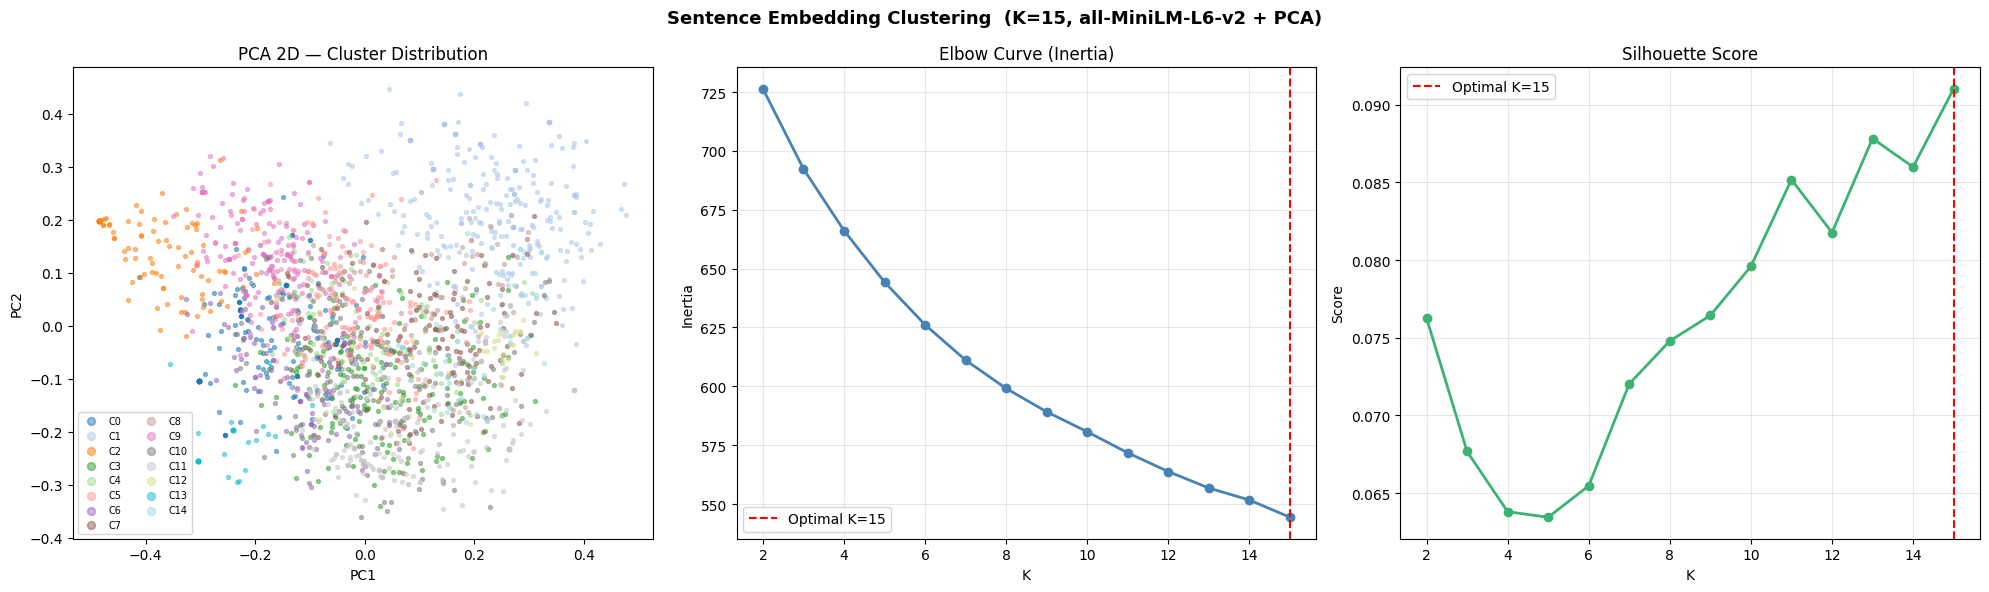

In [31]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from tqdm import tqdm

# ── 1. Embed reports ─────────────────────────────────────────────────
print("Loading SentenceTransformer model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')  # nhẹ, nhanh, tốt cho medical text

unique_reports = train_df['report'].str.strip().unique()
print(f"Embedding {len(unique_reports)} unique reports...")

embeddings_unique = embedder.encode(
    unique_reports,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

# Map embedding về toàn bộ train_df
report_to_idx = {r: i for i, r in enumerate(unique_reports)}
embeddings_all = np.array([
    embeddings_unique[report_to_idx[r.strip()]]
    for r in train_df['report']
])
print(f"Embedding shape: {embeddings_all.shape}")

# ── 2. Chọn số cluster tối ưu (Elbow + Silhouette) ───────────────────
K_range = range(2, 16)
inertias, silhouettes = [], []

print("\nFinding optimal K...")
for k in tqdm(K_range):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings_all)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(embeddings_all, labels, sample_size=1000, random_state=42))

# ── 3. Fit KMeans với K tối ưu ───────────────────────────────────────
OPTIMAL_K = K_range.start + int(np.argmax(silhouettes))
print(f"\n→ Optimal K by Silhouette: {OPTIMAL_K}")

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_all)
train_df['cluster'] = cluster_labels

# ── 4. Tìm report đại diện cho mỗi cluster ──────────────────────────
print("\n" + "="*70)
print(f"   CLUSTER SUMMARY  (K={OPTIMAL_K})")
print("="*70)

cluster_summary = []
for c in range(OPTIMAL_K):
    mask        = cluster_labels == c
    cluster_emb = embeddings_all[mask]
    center      = kmeans.cluster_centers_[c]
    dists       = np.linalg.norm(cluster_emb - center, axis=1)
    closest_idx = np.where(mask)[0][np.argmin(dists)]
    rep_report  = train_df['report'].iloc[closest_idx]

    cluster_summary.append({
        'Cluster': c,
        'Số report': mask.sum(),
        'Tỉ lệ (%)': round(mask.sum() / len(train_df) * 100, 2),
        'Report đại diện': rep_report[:80] + ('...' if len(rep_report) > 80 else '')
    })

summary_df = pd.DataFrame(cluster_summary).sort_values('Số report', ascending=False)
summary_df.index = range(1, len(summary_df) + 1)
print(summary_df.to_string(index=True))
print("="*70)

# ── 5. Top 3 report phổ biến nhất trong mỗi cluster ─────────────────
print("\n  TOP 3 REPORTS PHỔ BIẾN NHẤT TRONG MỖI CLUSTER")
print("-"*70)
for c in summary_df['Cluster']:
    sub = train_df[train_df['cluster'] == c]['report'].value_counts().head(3)
    print(f"\n  【Cluster {c}】 ({(cluster_labels==c).sum()} reports)")
    for rank, (report, cnt) in enumerate(sub.items(), 1):
        print(f"    #{rank} ({cnt}x) {report[:70]}{'...' if len(report)>70 else ''}")
print("-"*70)

# ── 6. Visualisation ─────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings_all)
colors = cm.tab20(np.linspace(0, 1, OPTIMAL_K))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"Sentence Embedding Clustering  (K={OPTIMAL_K}, all-MiniLM-L6-v2 + PCA)",
             fontsize=13, fontweight='bold')

# 6a. Scatter PCA
for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    color=colors[c], s=8, alpha=0.5, label=f'C{c}')
axes[0].set_title("PCA 2D — Cluster Distribution")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=2, fontsize=7, ncol=2)

# 6b. Elbow curve
axes[1].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[1].set_title("Elbow Curve (Inertia)")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Inertia")
axes[1].axvline(OPTIMAL_K, color='red', linestyle='--', label=f'Optimal K={OPTIMAL_K}')
axes[1].legend(); axes[1].grid(alpha=0.3)

# 6c. Silhouette score
axes[2].plot(list(K_range), silhouettes, 'o-', color='mediumseagreen', linewidth=2)
axes[2].set_title("Silhouette Score")
axes[2].set_xlabel("K"); axes[2].set_ylabel("Score")
axes[2].axvline(OPTIMAL_K, color='red', linestyle='--', label=f'Optimal K={OPTIMAL_K}')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**
- *Shilhouette Score* thấp (~ 0.065 -> 0.09) -> không có tách biệt rõ ràng trong không gian Embedding -> Phản ánh bản chất của Radiology Report: ngôn ngữ y khoa khá đồng nhất, ranh giới giữa "normal" và "mild abnormality" rất mờ nhạt về mặt ngữ nghĩa.
- 

In [33]:
import umap

# ── 1. Fit UMAP ──────────────────────────────────────────────────────
print("Fitting UMAP...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,       # láng giềng càng lớn → cấu trúc global càng rõ
    min_dist=0.1,         # điểm càng gần nhau trong cluster
    metric='cosine',      # phù hợp với sentence embeddings (đã normalize)
    random_state=42
)
coords_umap = reducer.fit_transform(embeddings_all)

# ── 2. Visualize ─────────────────────────────────────────────────────
colors = cm.tab20(np.linspace(0, 1, OPTIMAL_K))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f"UMAP Visualization — Sentence Embeddings (K={OPTIMAL_K})",
             fontsize=13, fontweight='bold')

# 2a. Tô màu theo cluster
for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    axes[0].scatter(
        coords_umap[mask, 0], coords_umap[mask, 1],
        color=colors[c], s=10, alpha=0.6, label=f'C{c} ({mask.sum()})'
    )
    # Vẽ tâm cluster
    cx, cy = coords_umap[mask, 0].mean(), coords_umap[mask, 1].mean()
    axes[0].scatter(cx, cy, color=colors[c], s=120, edgecolors='black', linewidths=1.2, zorder=5)
    axes[0].annotate(f'C{c}', (cx, cy), fontsize=8, fontweight='bold',
                     ha='center', va='center', color='black')

axes[0].set_title("UMAP — Colored by KMeans Cluster")
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
axes[0].legend(markerscale=2, fontsize=7, ncol=2,
               loc='upper right', bbox_to_anchor=(1.18, 1))

# 2b. Tô màu theo độ dài report (word count) → thấy correlation
sc = axes[1].scatter(
    coords_umap[:, 0], coords_umap[:, 1],
    c=train_df['report_word_count'],
    cmap='plasma', s=10, alpha=0.6
)
plt.colorbar(sc, ax=axes[1], label='Word count')
axes[1].set_title("UMAP — Colored by Report Length")
axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 